# Exploratory Data Analysis (EDA)

## Bluestock Mutual Fund Capstone Project

This notebook performs Exploratory Data Analysis (EDA) on the Mutual Fund datasets.

### Objectives

- Understand NAV trends
- Analyze AUM growth
- Study SIP inflows
- Explore investor demographics
- Analyze geographic distribution
- Study folio growth
- Compute NAV correlations
- Analyze portfolio sector allocation
- Generate insights for dashboard development

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

%matplotlib inline

In [15]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folios = pd.read_csv("../data/raw/06_industry_folio_count.csv")

transactions = pd.read_csv("../data/processed/transactions_clean.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [16]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Transactions": transactions,
    "Holdings": holdings
}

for name, df in datasets.items():
    print("=" * 50)
    print(name)
    print(df.shape)

Fund Master
(40, 15)
NAV History
(46000, 3)
AUM
(90, 5)
SIP
(48, 6)
Category
(144, 3)
Folios
(21, 6)
Transactions
(32778, 13)
Holdings
(322, 8)


## Daily NAV Trend

In [17]:
nav["date"] = pd.to_datetime(nav["date"])

In [18]:
top5 = nav["amfi_code"].unique()[:5]

top_nav = nav[
    nav["amfi_code"].isin(top5)
]

In [25]:
fig = px.line(
    top_nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (Top 5 Funds)"
)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-07-01",
    x1="2024-10-01",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.show()

## Insight 1

The selected mutual funds show a generally increasing NAV trend over time with short-term fluctuations, indicating long-term wealth creation potential.

## AUM Growth by Fund House (2022–2025)

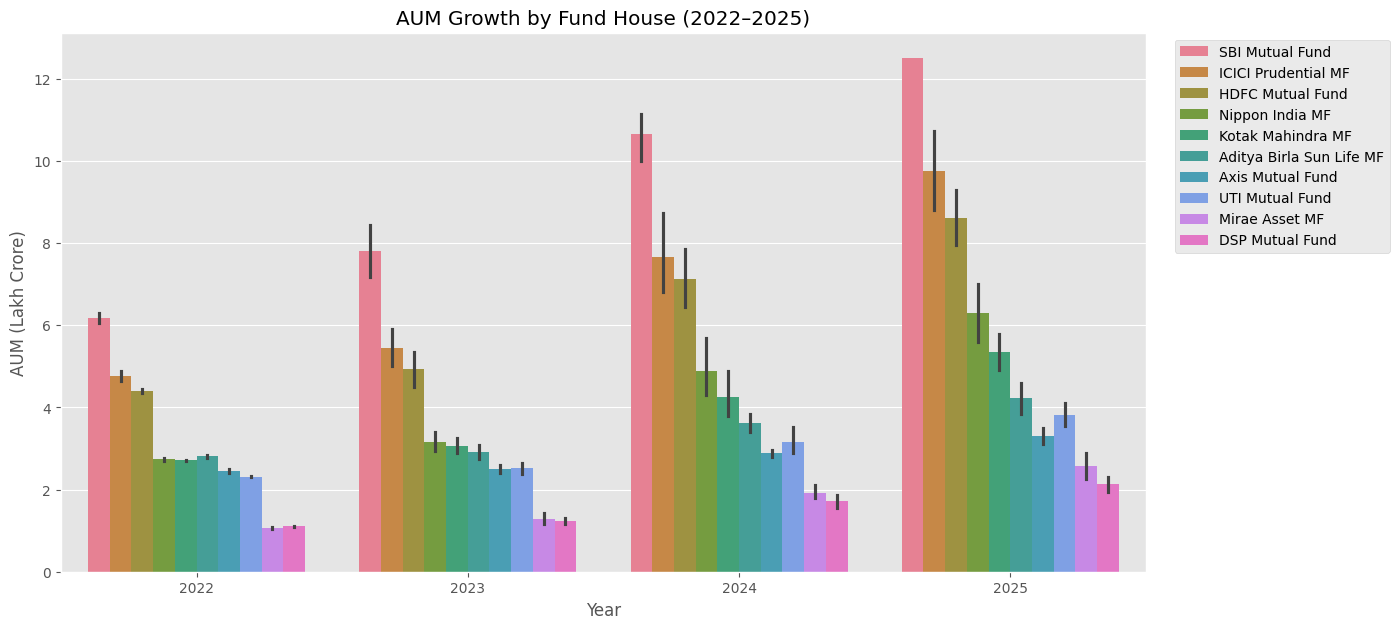

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.show()

## Insight 2

SBI Mutual Fund consistently maintained one of the highest AUM values among all fund houses, indicating strong investor confidence and market leadership.

## Monthly SIP Inflow Trend

In [22]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.add_annotation(
    x=sip.loc[sip["sip_inflow_crore"].idxmax(), "month"],
    y=sip["sip_inflow_crore"].max(),
    text="Highest SIP Inflow",
    showarrow=True,
    arrowhead=2
)

fig.show()

## Insight 3

Monthly SIP inflows show a steady upward trend, reflecting increasing retail participation in mutual funds.

## Category-wise Net Inflow Heatmap

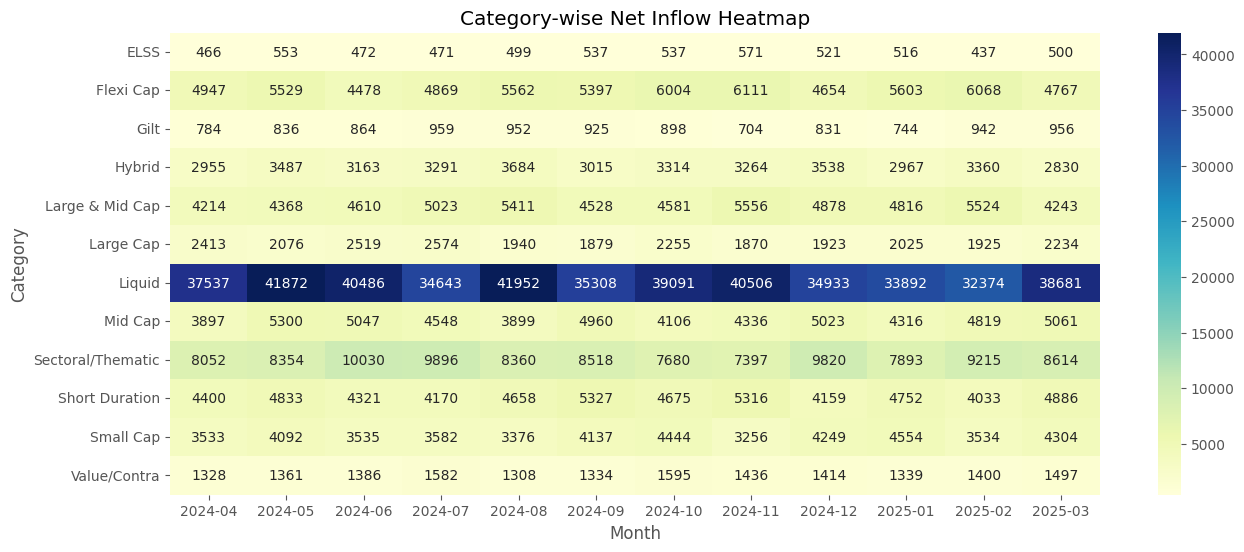

In [23]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

## Insight 4

Flexi Cap and Mid Cap funds attracted higher net inflows during several months compared to other categories.

## Folio Growth ( Industry Folio Growth)

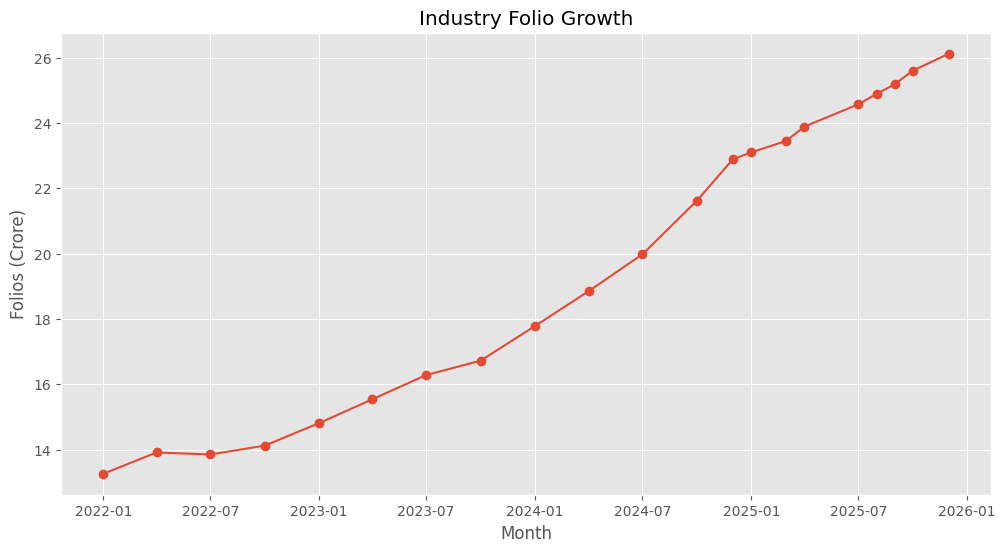

In [24]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.show()

## Insight 5

The total number of mutual fund folios increased consistently, indicating growing investor participation.

## Investor Age Group Distribution

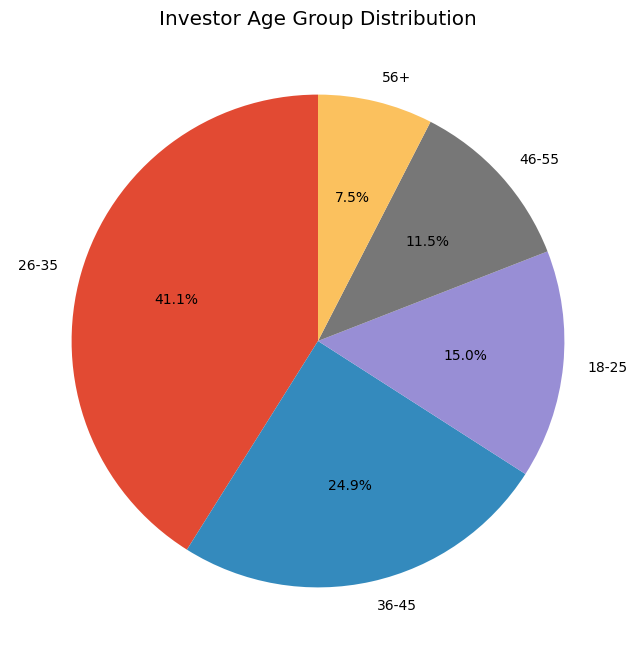

In [26]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

## Insight 6

Most investors belong to the young and middle-aged categories, showing strong participation from working professionals.

## SIP Amount by Age Group (Box Plot)

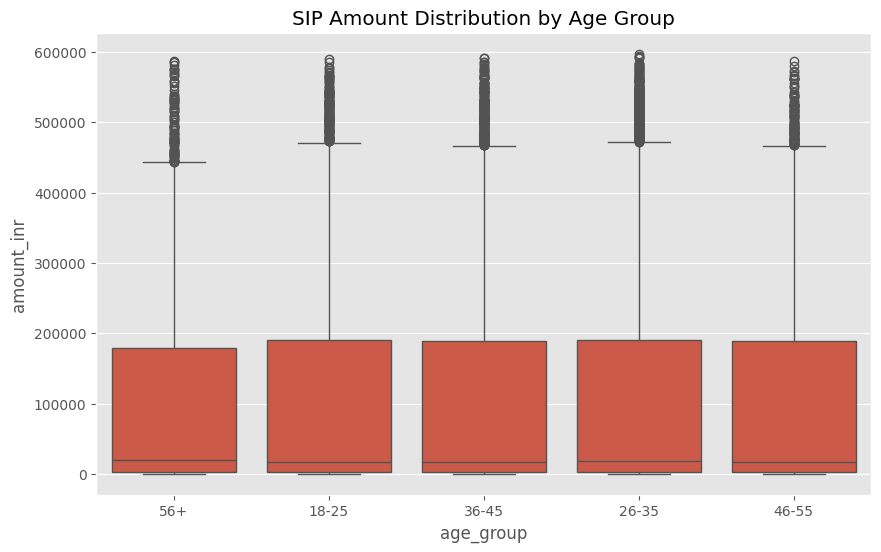

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.show()

## Insight 7

Older investors generally invest larger amounts, while younger investors show more variability in SIP sizes.

## Gender Distributio

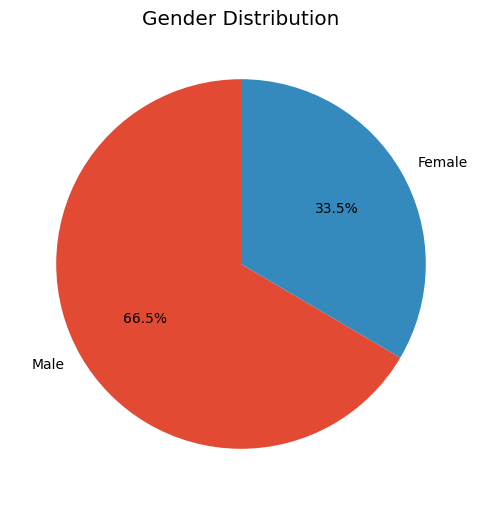

In [28]:
gender = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

## Insight 8

The investor base is distributed across genders, indicating broad participation in mutual fund investments.

## Geographic Distribution (State-wise Investment)

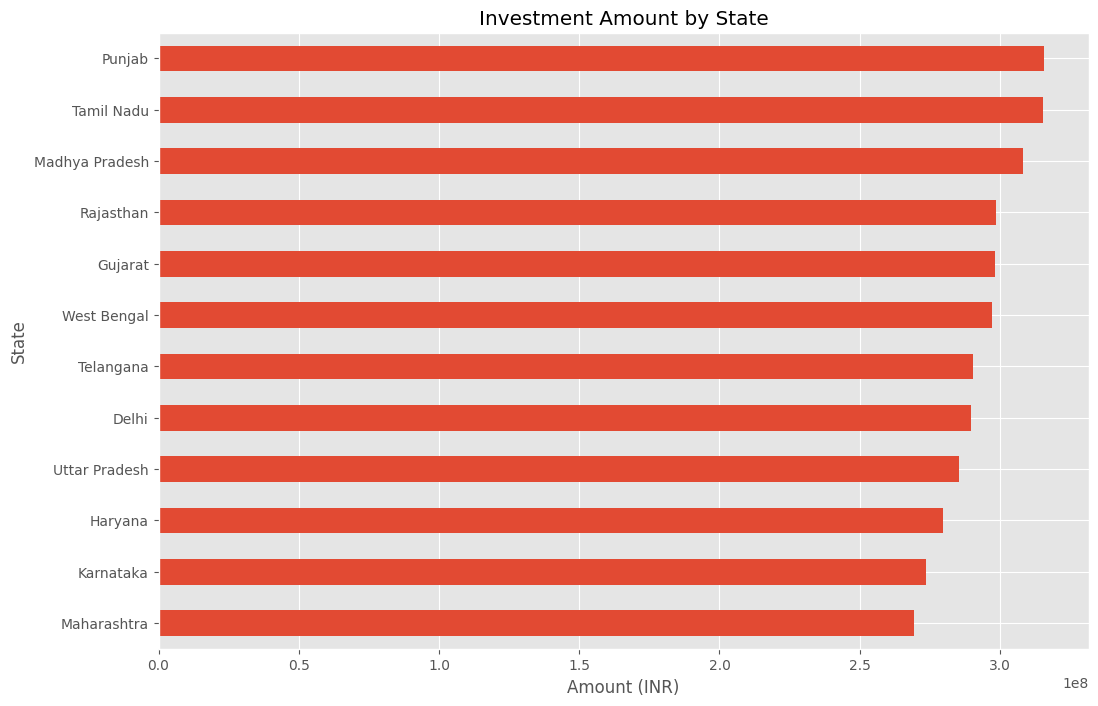

In [29]:
state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,8))

state_data.plot(kind="barh")

plt.title("Investment Amount by State")

plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.show()

## Insight 9

A few states contribute a significantly larger share of total investments than others.

## City Tier Distribution

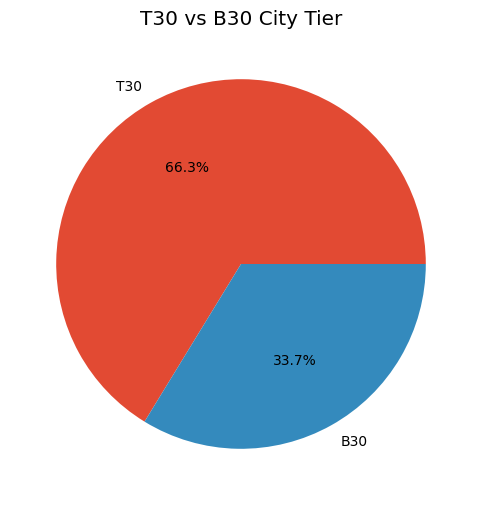

In [30]:
tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Tier")

plt.show()

## NAV Return Correlation Matrix

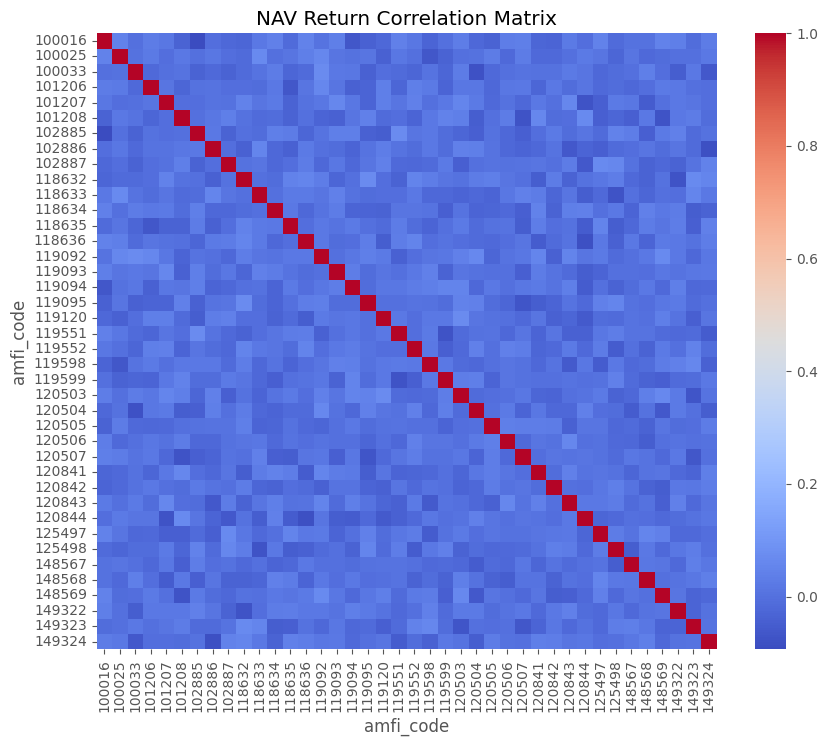

In [31]:
returns = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = returns.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

## Insight 11

Most equity funds exhibit positive correlations because they respond similarly to market movements.

## Sector Allocation (Donut Chart)

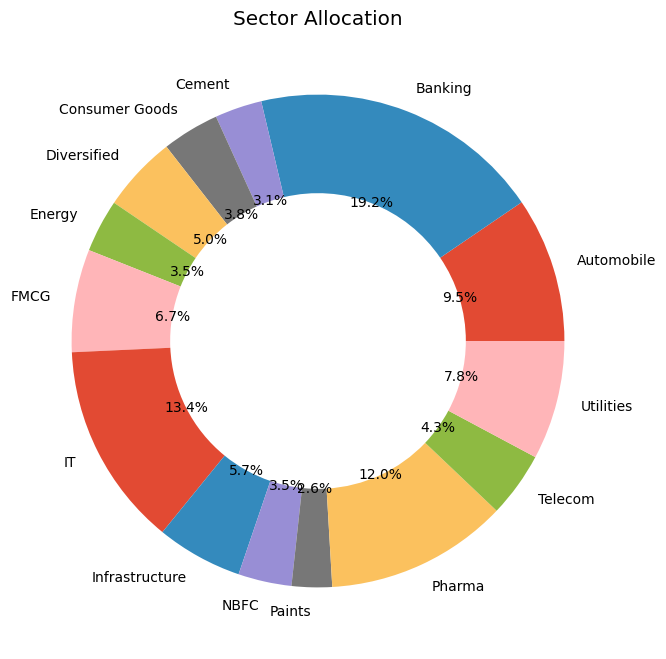

In [32]:
sector = holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation")

plt.show()

## Insight 12

Financials and Information Technology account for a large portion of equity fund portfolios.

# EDA Summary

### Key Findings

1. Mutual fund NAVs generally increased over the study period.
2. SBI Mutual Fund maintained one of the highest AUM values.
3. SIP inflows increased steadily over time.
4. Flexi Cap and Mid Cap funds attracted strong investor interest.
5. Total folios nearly doubled, indicating growing participation.
6. Young and middle-aged investors dominate the market.
7. Higher age groups tend to invest larger SIP amounts.
8. Investments are concentrated in a few major states.
9. T30 cities contribute most investments.
10. Equity fund returns show strong positive correlation.
11. Financials and IT dominate sector allocation.
12. The mutual fund industry continues to grow in both assets and investor participation.